In [1]:
import matplotlib.pyplot as plt
import finitewave as fw


def run_model(model, t_max):
    # create a tissue of size 100x10 with cardiomycytes:
    n = 100
    m = 1
    tissue = fw.CardiacTissue([n, m], dr=0.25)

    # set up stimulation parameters:
    stim_sequence = fw.StimSequence()
    stim_sequence.add_stim(fw.StimVoltageCoord(time=0, volt_value=1,
                                               x_min=0, x_max=5,
                                               y_min=0, y_max=m))

    action_pot_tracker = fw.ActionPotentialTracker()
    action_pot_tracker.node_inds = [[n//2, 0]]
    action_pot_tracker.step = 1

    tracker_sequence = fw.TrackerSequence()
    tracker_sequence.add_tracker(action_pot_tracker)

    # create model object and set up parameters:
    simulation = fw.CardiacSimulation(dt=0.01, t_max=t_max, backend="numba")
    simulation.cardiac_model = model
    simulation.cardiac_tissue = tissue
    simulation.stim_sequence = stim_sequence
    simulation.tracker_sequence = tracker_sequence

    # run the model:
    simulation.run()

    return action_pot_tracker.tracking_times, action_pot_tracker.output

Running Courtemanche on [100, 1] Grid: 100%|██████████| 50000/50000 [00:04<00:00, 11769.75it/s]


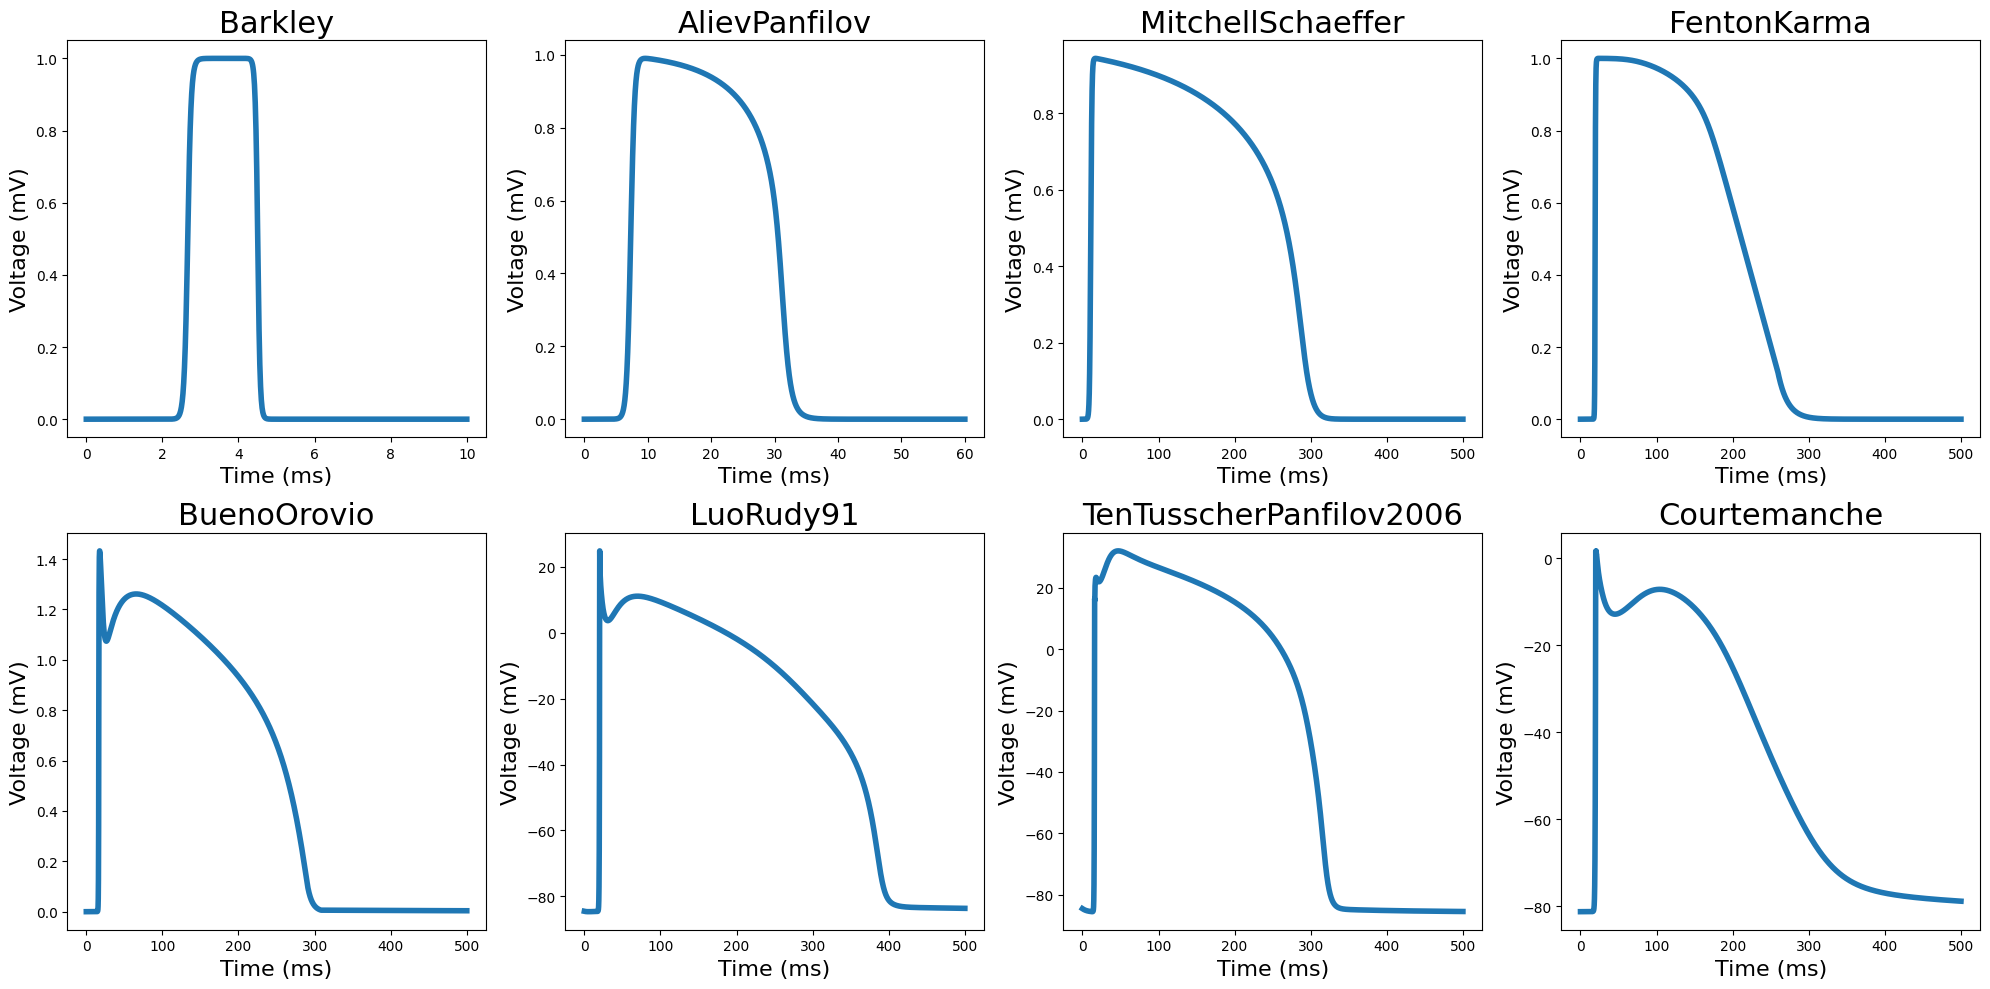

In [6]:
models = [fw.Barkley(), fw.AlievPanfilov(), fw.MitchellSchaeffer(), 
          fw.FentonKarma(), fw.BuenoOrovio(), fw.LuoRudy91(),
          fw.TenTusscherPanfilov2006(), fw.Courtemanche()]

t_max = [10, 60, 500, 500, 500, 500, 500, 500]

ap_times = []
ap_values = []
for i, model in enumerate(models):
    ap_times_, ap_values_ = run_model(model, t_max=t_max[i])

    ap_times.append(ap_times_)
    ap_values.append(ap_values_)

fig, axs = plt.subplots(2, 4, figsize=(20, 10))
for i, model in enumerate(models):
    ax = axs[i//4, i%4]
    ax.plot(ap_times[i], ap_values[i], lw=4)
    ax.set_title(model.__class__.__name__, fontsize=22)
    ax.set_xlabel("Time (ms)", fontsize=16)
    ax.set_ylabel("Voltage (mV)", fontsize=16)
plt.tight_layout()
plt.show()